# Evaluation — monolingual vs. multilingual RAG

Compares the two RAG setups across three dimensions:
1. **Retrieval quality** — does the relevant section appear in the top-K results?
2. **Answer quality** — LLM-as-judge content scoring (1–5)
3. **Terminology** — exact and semantic presence of the target term in the answer

> **Prerequisites**: run `mono_rag.ipynb` and `multi_rag.ipynb` first to build both ChromaDB collections.

### Content
* Section 0: Setup
* Section 1: Retrieval and generation evaluation
* Section 2: Answer quality (content)
* Section 3: Terminology evaluation
* Section 4: Summary and export

## Section 0 — Setup

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb
import ollama
from sentence_transformers import SentenceTransformer, CrossEncoder

from chunking   import load_documents, build_chunk_records
from retrieval  import build_bm25_index, retrieve
from generation import ask, build_user_message, SYSTEM_PROMPT, detect_language
from config     import EMBED_MODEL, CE_MODEL, TOP_K, BM25_WEIGHT, SEMANTIC_POOL, RERANK_POOL, GENERATION_MODEL, JUDGE_MODEL

# Run flags 
RUN_EVALUATION  = True   # retrieve + generate in one pass
RUN_JUDGE       = True   # LLM judge scoring (reads from saved CSV)
RUN_TERMINOLOGY = True   # terminology checks (reads from saved CSV)

# RAG configurations
CFG_MONO = {
    "TOP_K": TOP_K, "BM25_WEIGHT": BM25_WEIGHT, "SEMANTIC_POOL": SEMANTIC_POOL, "RERANK_POOL": RERANK_POOL,
    "MODEL_NAME":      GENERATION_MODEL,
    "COLLECTION_NAME": "fdv_de_only",
    "CHROMA_DIR":      "chroma_db_de",
    "DATA_DIRS":       {"de": Path("data/de")},
}
CFG_MULTI = {
    "TOP_K": TOP_K, "BM25_WEIGHT": BM25_WEIGHT, "SEMANTIC_POOL": SEMANTIC_POOL, "RERANK_POOL": RERANK_POOL,
    "MODEL_NAME":      GENERATION_MODEL,
    "COLLECTION_NAME": "fdv_multilingual",
    "CHROMA_DIR":      "chroma_db_multilingual",
    "DATA_DIRS":       {"de": Path("data/de"),
                        "fr": Path("data/fr"),
                        "it": Path("data/it")},
}

QUESTIONS_FILE = Path("questions.csv")
ANSWERS_EXPORT = Path("results/answers_export.csv")
RESULTS_EXPORT = Path("results/evaluation_results.csv")

Path("results").mkdir(exist_ok=True)

print(f"Generation model : {GENERATION_MODEL}")
print(f"Judge model      : {JUDGE_MODEL}")
print(f"RUN_EVALUATION   : {RUN_EVALUATION}")
print(f"RUN_JUDGE        : {RUN_JUDGE}")
print(f"RUN_TERMINOLOGY  : {RUN_TERMINOLOGY}")

c:\Users\niw\Documents\CAS_NLP_Project\Project_tRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generation model : gemma3:4b
Judge model      : phi4-mini
RUN_EVALUATION   : True
RUN_JUDGE        : True
RUN_TERMINOLOGY  : True


In [2]:
# Load shared models once for both setups
print("Loading embedding model...")
embedder = SentenceTransformer(EMBED_MODEL)
print("Loading cross-encoder...")
cross_encoder = CrossEncoder(CE_MODEL)

def _load_rag_system(cfg):
    docs = []
    for lang, data_dir in cfg["DATA_DIRS"].items():
        docs.extend(load_documents(data_dir, lang))
    records = build_chunk_records(docs)
    bm25    = build_bm25_index(records)
    client  = chromadb.PersistentClient(path=str(cfg["CHROMA_DIR"]))
    coll    = client.get_or_create_collection(
        name=cfg["COLLECTION_NAME"],
        metadata={"hnsw:space": "cosine"},
    )
    assert coll.count() > 0, (
        f"Collection '{cfg['COLLECTION_NAME']}' is empty — "
        "run mono_rag.ipynb / multi_rag.ipynb first."
    )
    assert coll.count() == len(records), (
        f"ChromaDB has {coll.count()} chunks but chunk_records has {len(records)}. "
        "Delete the chroma_db_* folder and re-run mono_rag.ipynb / multi_rag.ipynb."
    )
    print(f"  {cfg['COLLECTION_NAME']}: {coll.count()} chunks, {len(records)} records")
    return records, bm25, coll

print("\nLoading mono_rag...")
chunks_mono, bm25_mono, coll_mono = _load_rag_system(CFG_MONO)
print("Loading multi_rag...")
chunks_multi, bm25_multi, coll_multi = _load_rag_system(CFG_MULTI)
print("\nBoth systems ready.")

Loading embedding model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2478.44it/s]
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cross-encoder...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2024.02it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loading mono_rag...
  fdv_de_only: 1360 chunks, 1360 records
Loading multi_rag...
  fdv_multilingual: 4272 chunks, 4272 records

Both systems ready.


In [3]:
# Load questions and parse expected section
def parse_section(s):
    """'R 300.4, section 2.3.7' -> ('R 300.4', '2.3.7')"""
    s = str(s).strip()
    s = re.sub(r'\bR(\d)', r'R \1', s)          # normalise R300.x -> R 300.x
    m = re.split(r',\s*section\s+', s, flags=re.IGNORECASE)
    return (m[0].strip(), m[1].strip()) if len(m) == 2 else (s, "")

def check_hit(results, expected_reg, expected_sec):
    """
    A hit is counted if any top-K result:
    1. Has exact metadata match (regulation_number + section_id), OR
    2. Belongs to the right regulation AND the expected section heading
       appears in the chunk text — handles cases where a short section
       was merged into an adjacent chunk and is labeled with a different id.
    """
    sec_pattern = re.compile(
        r'(?:^|\n)\t?' + re.escape(str(expected_sec)) + r'\t',
    )
    for r in results:
        if r.get("regulation_number", "").strip() != expected_reg:
            continue
        # Exact metadata match
        if str(r.get("section_id", "")).strip() == str(expected_sec).strip():
            return True
        # Section heading present in chunk text
        if sec_pattern.search(r.get("text", "")):
            return True
    return False

def _generate(chunks, query, lang_name, cfg):
    user_msg = build_user_message(query, chunks, lang_name)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_msg},
    ]
    try:
        resp = ollama.chat(
            model=cfg["MODEL_NAME"],
            messages=messages,
            options={"temperature": 0.1},
        )
        return resp.message.content
    except Exception as exc:
        return f"[Ollama error: {exc}]"

df_q = pd.read_csv(QUESTIONS_FILE)
df_q.columns = [c.strip() for c in df_q.columns]
df_q[["reg_num", "sec_id"]] = df_q["Relevant section"].apply(
    lambda s: pd.Series(parse_section(s))
)

print(f"{len(df_q)} questions loaded.")
display(df_q.head(6))

66 questions loaded.


,ID,Source Term,Query,Language,Relevant section,Target Term,reg_num,sec_id
0,1,Heizer,Was macht ein Heizer?,de,"R 300.13, section 1.1",Feuerung,R 300.13,1.1
1,2,Heizer,Quelles sont les fonctions du chauffeur?,fr,"R 300.13, section 1.1",foyer,R 300.13,1.1
2,3,Heizer,Cosa fa un fuochista?,it,"R 300.13, section 1.1",regolazione del fuoco,R 300.13,1.1
3,4,Abstossen,Welche Arten von Rangierbewegungen gibt es?,de,"R 300.4, section 1.3",abstossen,R 300.4,1.3
4,5,Abstossen,Quels genres de mouvements de manoeuvre distin...,fr,"R 300.4, section 1.3",lancer,R 300.4,1.3
5,6,Abstossen,Quali tipi di movimenti di manovra si disting...,it,"R 300.4, section 1.3",colpo,R 300.4,1.3


## Section 1 — Retrieval & Generation Evaluation

Retrieves relevant chunks for each question using both setups, checks hits, and generates
answers from the same retrieved chunks. Saves everything to `answers_export.csv` —
Sections 2 & 3 can reload from that file without re-running the evaluation.

In [4]:
if not RUN_EVALUATION:
    print("RUN_EVALUATION is False — skipping. Sections below will reload from saved CSV.")
else:
    eval_rows = []
    total = len(df_q)
    for i, row in df_q.iterrows():
        print(f"  [{i+1}/{total}] {row['Query'][:70]}", end="\r")

        # Retrieve once per system — used for both hit check and generation
        chunks_mono_ret  = retrieve(row["Query"], embedder, cross_encoder,
                                    coll_mono,  bm25_mono,  chunks_mono,  CFG_MONO)
        chunks_multi_ret = retrieve(row["Query"], embedder, cross_encoder,
                                    coll_multi, bm25_multi, chunks_multi, CFG_MULTI)

        # Hit check against the exact chunks that will be used for generation
        hit_mono  = check_hit(chunks_mono_ret,  row["reg_num"], row["sec_id"])
        hit_multi = check_hit(chunks_multi_ret, row["reg_num"], row["sec_id"])

        # Generate answers from those same chunks
        lang_name = detect_language(row["Query"])
        ans_mono  = _generate(chunks_mono_ret,  row["Query"], lang_name, CFG_MONO)
        ans_multi = _generate(chunks_multi_ret, row["Query"], lang_name, CFG_MULTI)

        eval_rows.append({
            "ID":               row["ID"],
            "Source Term":      row["Source Term"],
            "Query":            row["Query"],
            "Language":         row["Language"],
            "Relevant section": row["Relevant section"],
            "Target Term":      row["Target Term"],
            # retrieval
            "hit_mono":         hit_mono,
            "hit_multi":        hit_multi,
            "rerank_mono":      chunks_mono_ret[0]["rerank_score"]  if chunks_mono_ret  else None,
            "rerank_multi":     chunks_multi_ret[0]["rerank_score"] if chunks_multi_ret else None,
            # top retrieved chunk used as generation basis (for cross-checking and judging)
            "ref_mono":         chunks_mono_ret[0]["text"]  if chunks_mono_ret  else "",
            "ref_multi":        chunks_multi_ret[0]["text"] if chunks_multi_ret else "",
            "src_mono":         (chunks_mono_ret[0].get("regulation_number","") + " §" +
                                 chunks_mono_ret[0].get("section_id",""))
                                if chunks_mono_ret  else "",
            "src_multi":        (chunks_multi_ret[0].get("regulation_number","") + " §" +
                                 chunks_multi_ret[0].get("section_id",""))
                                if chunks_multi_ret else "",
            # answers
            "answer_mono":      ans_mono,
            "answer_multi":     ans_multi,
        })

    df_answers = pd.DataFrame(eval_rows)
    df_answers.to_csv(ANSWERS_EXPORT, index=False, encoding="utf-8-sig")
    print(f"\nEvaluation complete. {len(df_answers)} rows saved to {ANSWERS_EXPORT}")

  [66/66] Quando è vietata la memorizzazione dei percorsi durante le corse di ma
Evaluation complete. 66 rows saved to results\answers_export.csv


In [5]:
if not RUN_EVALUATION or "df_answers" not in dir():
    print("RUN_EVALUATION is False — skipping retrieval summary.")
else:
    n = len(df_answers)

    # Overall hit rate
    print(f"{'Setup':<12} {'Hits':>6} {'Total':>6} {'Hit rate':>10}")
    print("-" * 38)
    for setup, col in [("mono_rag", "hit_mono"), ("multi_rag", "hit_multi")]:
        hits = int(df_answers[col].sum())
        print(f"{setup:<12} {hits:>6} {n:>6} {100*hits/n:>9.1f}%")

    # By language
    lang_r = df_answers.groupby("Language")[["hit_mono", "hit_multi"]].mean() * 100
    lang_r.columns = ["mono_rag (%)", "multi_rag (%)"]
    print("\nHit rate by language:"); display(lang_r.round(1))

    # By regulation
    _df_r = df_answers.merge(df_q[["ID", "reg_num"]], on="ID", how="left")
    reg_r = _df_r.groupby("reg_num")[["hit_mono", "hit_multi"]].mean() * 100
    reg_r.columns = ["mono_rag (%)", "multi_rag (%)"]
    reg_r = reg_r.sort_index(key=lambda s: s.str.extract(r'(\d+)$')[0].astype(int))
    print("\nHit rate by regulation:"); display(reg_r.round(1))

    # Rerank scores: hits vs. misses
    print("\nMean top-1 rerank score — hits vs. misses:")
    for setup, hc, sc in [("mono_rag", "hit_mono", "rerank_mono"),
                           ("multi_rag", "hit_multi", "rerank_multi")]:
        h = df_answers.loc[df_answers[hc] == True,  sc].mean()
        m = df_answers.loc[df_answers[hc] == False, sc].mean()
        print(f"  {setup:<12}  hits={h:.3f}  misses={m:.3f}")

Setup          Hits  Total   Hit rate
--------------------------------------
mono_rag         38     66      57.6%
multi_rag        60     66      90.9%

Hit rate by language:


,mono_rag (%),multi_rag (%)
Language,,
de,90.9,90.9
fr,31.8,90.9
it,50.0,90.9



Hit rate by regulation:


,mono_rag (%),multi_rag (%)
reg_num,,
R 300.1,0.0,0.0
R 300.2,100.0,100.0
R 300.4,60.0,100.0
R 300.5,50.0,100.0
R 300.6,66.7,100.0
R 300.7,100.0,100.0
R 300.8,100.0,100.0
R 300.9,22.2,66.7
R 300.12,66.7,100.0



Mean top-1 rerank score — hits vs. misses:
  mono_rag      hits=5.256  misses=-0.504
  multi_rag     hits=7.463  misses=3.899


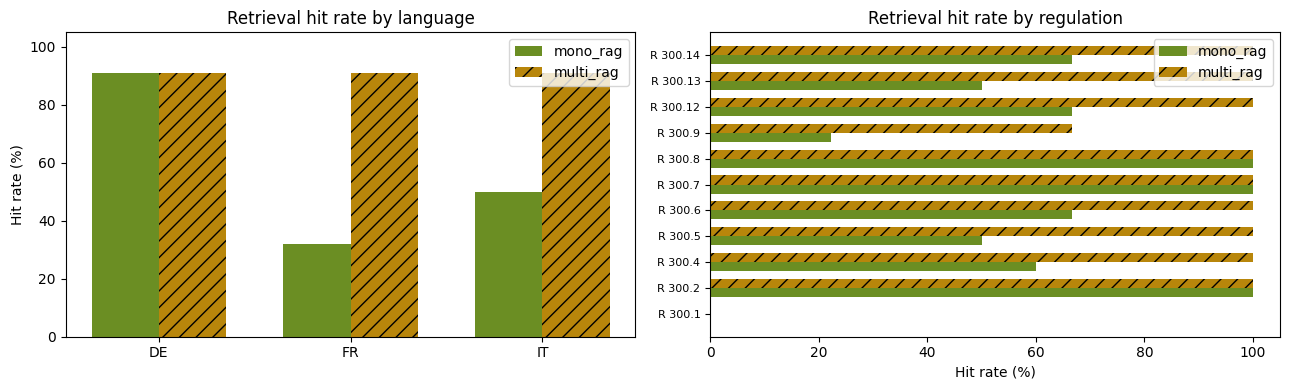

In [6]:
# Chart: retrieval hit rate by language and regulation
if not RUN_EVALUATION or "lang_r" not in dir() or "reg_r" not in dir():
    print("Run the retrieval summary cell first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    langs = lang_r.index.tolist(); x = np.arange(len(langs)); w = 0.35
    axes[0].bar(x - w/2, lang_r["mono_rag (%)"],  w, label="mono_rag",  color="olivedrab")
    axes[0].bar(x + w/2, lang_r["multi_rag (%)"], w, label="multi_rag", color="darkgoldenrod", hatch="//")
    axes[0].set_xticks(x); axes[0].set_xticklabels([l.upper() for l in langs])
    axes[0].set_ylabel("Hit rate (%)"); axes[0].set_ylim(0, 105)
    axes[0].set_title("Retrieval hit rate by language"); axes[0].legend()

    regs = reg_r.index.tolist(); y = np.arange(len(regs))
    axes[1].barh(y - w/2, reg_r["mono_rag (%)"],  w, label="mono_rag",  color="olivedrab")
    axes[1].barh(y + w/2, reg_r["multi_rag (%)"], w, label="multi_rag", color="darkgoldenrod", hatch="//")
    axes[1].set_yticks(y); axes[1].set_yticklabels(regs, fontsize=8)
    axes[1].set_xlabel("Hit rate (%)"); axes[1].set_xlim(0, 105)
    axes[1].set_title("Retrieval hit rate by regulation"); axes[1].legend()
    plt.tight_layout(); plt.show()

### Single retrieval check

In [5]:
# Deep-dive on a specific query
# Change INSPECT_ID to investigate any retrieval miss
if not RUN_EVALUATION:
    print("RUN_EVALUATION is False — skipping deep-dive.")
else:
    INSPECT_ID = 6

    row     = df_q[df_q["ID"] == INSPECT_ID].iloc[0]
    query   = row["Query"]
    exp_reg = row["reg_num"]
    exp_sec = row["sec_id"]

    print(f"ID {INSPECT_ID}: {query}")
    print(f"Expected: {exp_reg} §{exp_sec}\n")

    res_mono  = retrieve(query, embedder, cross_encoder,
                         coll_mono,  bm25_mono,  chunks_mono,  CFG_MONO)
    res_multi = retrieve(query, embedder, cross_encoder,
                         coll_multi, bm25_multi, chunks_multi, CFG_MULTI)

    sec_pattern = re.compile(r'(?:^|\n)\t?' + re.escape(str(exp_sec)) + r'\t')

    for label, results in [("mono_rag", res_mono), ("multi_rag", res_multi)]:
        print(f"{'\u2500'*68}")
        print(f"{label}:")
        for j, r in enumerate(results, 1):
            reg      = r.get("regulation_number", "")
            sid      = r.get("section_id", "")
            lang     = r.get("language", "")
            meta_hit = reg == exp_reg and str(sid).strip() == str(exp_sec).strip()
            text_hit = reg == exp_reg and bool(sec_pattern.search(r.get("text", "")))
            flag     = "\u2713 HIT (meta)" if meta_hit else "\u2713 HIT (text)" if text_hit else "\u2717 miss"
            print(f"  [{j}] {flag:14}  [{lang.upper()}] {reg} §{sid}"
                  f"  rerank={r['rerank_score']:+.3f}  sem={r['sem_score']:.3f}"
                  f"  bm25={r['bm25_score']:.3f}")
            print(f"       {r['text'][:120].strip()!r}")
    print(f"{'\u2500'*68}")

ID 6: Quali tipi di movimenti di  manovra si distinguono?
Expected: R 300.4 §1.3

────────────────────────────────────────────────────────────────────
mono_rag:
  [1] ✗ miss          [DE] R 300.4 §7.1.2  rerank=+3.461  sem=0.777  bm25=0.500
       '7.1.2\tBewegungsarten\t\n\t\t\n\tEs wird zwischen folgenden Rangierbewegungen unterschieden:\n-\tRangierfahrten direkt und indire'
  [2] ✓ HIT (meta)    [DE] R 300.4 §1.3  rerank=+3.284  sem=0.773  bm25=0.500
       '1.3\tBewegungsarten\n\t\n\tEs wird zwischen folgenden Rangierbewegungen unterschieden:\n–\tRangierfahrten direkt und indirekt g'
────────────────────────────────────────────────────────────────────
multi_rag:
  [1] ✓ HIT (meta)    [IT] R 300.4 §1.3  rerank=+10.613  sem=0.920  bm25=0.978
       '1.3\tTipi di movimento\n\t\n\tSi distingue fra i movimenti di manovra seguenti:\n–\tcorse di manovra condotte direttamente e in'
  [2] ✗ miss          [IT] R 300.4 §7.1.2  rerank=+10.327  sem=0.923  bm25=1.000
       '7.1.2\tTipi di movim

## Section 2 — Answer Quality (Content)

LLM-as-judge (`JUDGE_MODEL`) rates each answer, attributing a score between 1–5, given the question and the reference section text from the source documents.

In [6]:
if not RUN_JUDGE:
    print("RUN_JUDGE is False — skipping content scoring.")
else:
    # Reload answers from file if not already in memory
    try:
        df_answers
        print(f"Using {len(df_answers)} answers already in memory.")
    except NameError:
        if ANSWERS_EXPORT.exists():
            df_answers = pd.read_csv(ANSWERS_EXPORT)
            print(f"Loaded {len(df_answers)} answers from {ANSWERS_EXPORT}")
        else:
            raise FileNotFoundError(
                f"{ANSWERS_EXPORT} not found. Run the evaluation cell with RUN_EVALUATION=True first."
            )

    JUDGE_SYSTEM = (
        "You are an evaluation assistant. Rate how well the RAG answer responds to the "
        "question based on the reference passage from the source document.\n"
        "Scale: 5 = fully correct and complete and using the correct terminology from "
        "the source document, 4 = mostly correct with minor gaps, 3 = partially correct, "
        "2 = mostly incorrect, 1 = completely wrong or not the same language as the query.\n"
        "Reply with only: SCORE: <1-5>\nREASON: <one sentence>"
    )

    def _llm_judge(query, ref_text, answer):
        user_msg = (
            f"Question: {query}\n\n"
            f"Reference passage:\n{ref_text}\n\n"
            f"RAG answer:\n{answer}"
        )
        try:
            resp = ollama.chat(
                model=JUDGE_MODEL,
                messages=[
                    {"role": "system", "content": JUDGE_SYSTEM},
                    {"role": "user",   "content": user_msg},
                ],
                options={"temperature": 0.0},
            )
            raw   = resp.message.content.strip()
            score, reason = None, ""
            for line in raw.splitlines():
                if line.upper().startswith("SCORE:"):
                    try: score = int(line.split(":", 1)[1].strip()[0])
                    except: pass
                elif line.upper().startswith("REASON:"):
                    reason = line.split(":", 1)[1].strip()
            return score, reason
        except Exception as e:
            return None, str(e)

    df_j = df_answers.copy()

    s_mono, r_mono, s_multi, r_multi = [], [], [], []
    total = len(df_j)
    for i, row in df_j.iterrows():
        print(f"  Judging [{i+1}/{total}]...", end="\r")
        sm,  rm  = _llm_judge(row["Query"], row["ref_mono"],  row["answer_mono"])
        sml, rml = _llm_judge(row["Query"], row["ref_multi"], row["answer_multi"])
        s_mono.append(sm);  r_mono.append(rm)
        s_multi.append(sml); r_multi.append(rml)

    df_j["judge_score_mono"]   = s_mono
    df_j["judge_reason_mono"]  = r_mono
    df_j["judge_score_multi"]  = s_multi
    df_j["judge_reason_multi"] = r_multi
    df_j["judge_delta"] = (
        pd.to_numeric(df_j["judge_score_multi"], errors="coerce") -
        pd.to_numeric(df_j["judge_score_mono"],  errors="coerce")
    )
    print(f"\nJudging complete.")

    # Per-question table
    display(df_j[["ID", "Language", "Query",
                  "judge_score_mono", "judge_score_multi", "judge_delta"]]
            .style.background_gradient(subset=["judge_delta"],
                                       cmap="RdYlGn", vmin=-4, vmax=4))

    # By language
    lang_j = df_j.groupby("Language")[["judge_score_mono", "judge_score_multi"]].mean()
    lang_j.columns = ["mono_rag", "multi_rag"]
    print("\nMean judge score by language:"); display(lang_j.round(2))

    print(f"\nOverall — mono_rag: {df_j['judge_score_mono'].mean():.2f}  "
          f"multi_rag: {df_j['judge_score_multi'].mean():.2f}  "
          f"delta: {df_j['judge_delta'].mean():+.2f}")

Loaded 66 answers from results\answers_export.csv
  Judging [66/66]...
Judging complete.


,ID,Language,Query,judge_score_mono,judge_score_multi,judge_delta
0,1,de,Was macht ein Heizer?,5,5,0
1,2,fr,Quelles sont les fonctions du chauffeur?,1,4,3
2,3,it,Cosa fa un fuochista?,5,5,0
3,4,de,Welche Arten von Rangierbewegungen gibt es?,5,5,0
4,5,fr,Quels genres de mouvements de manoeuvre distingue-t-on?,5,4,-1
5,6,it,Quali tipi di movimenti di manovra si distinguono?,4,4,0
6,7,de,Unter welchen Bedingungen sind Rangierfahrten gegen eingestellte Zugfahrstrassen erlaubt?,4,4,0
7,8,fr,Dans quelles conditions les courses de manœuvre en direction d'itinéraires de train établis sont-elles autorisées?,5,4,-1
8,9,it,In quali condizioni sono ammessi i movimenti di manovra verso percorsi treni disposti?,5,5,0
9,10,de,Welche Fahrzeuge dürfen nicht in Züge eingereiht werden?,2,2,0



Mean judge score by language:


,mono_rag,multi_rag
Language,,
de,4.45,4.45
fr,3.82,4.00
it,3.23,4.32



Overall — mono_rag: 3.83  multi_rag: 4.26  delta: +0.42


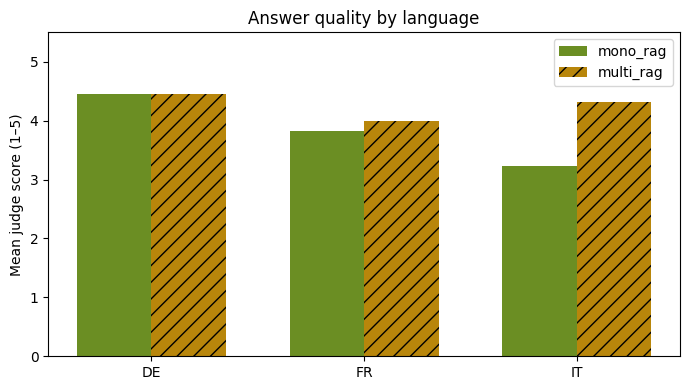

In [7]:
# Chart: answer quality (judge score) by language
if not RUN_JUDGE or "lang_j" not in dir():
    print("Run the judge scoring cell first.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    langs = lang_j.index.tolist(); x = np.arange(len(langs)); w = 0.35
    ax.bar(x - w/2, lang_j["mono_rag"],  w, label="mono_rag",  color="olivedrab")
    ax.bar(x + w/2, lang_j["multi_rag"], w, label="multi_rag", color="darkgoldenrod", hatch="//")
    ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
    ax.set_ylabel("Mean judge score (1–5)"); ax.set_ylim(0, 5.5)
    ax.set_title("Answer quality by language"); ax.legend()
    plt.tight_layout(); plt.show()

Loaded judge scores from results\evaluation_results.csv (66 rows).

Mean judge score (1–5) — retrieval hits only:

Language    mono_rag mean    n   multi_rag mean    n
────────────────────────────────────────────────────
DE                   4.35   20             4.40   20
FR                   4.57    7             3.85   20
IT                   3.64   11             4.20   20
────────────────────────────────────────────────────
Overall              4.18   38             4.15   60


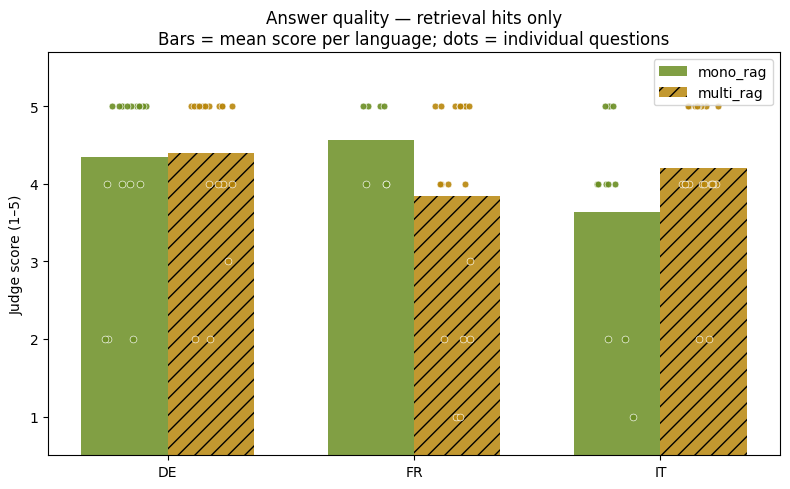

In [2]:
# Answer quality — restricted to retrieval hits
# Load source data: prefer in-memory df_j, fall back to saved results CSV
try:
    _df_jh = df_j[["ID", "Language", "hit_mono", "hit_multi",
                    "judge_score_mono", "judge_score_multi"]].copy()
    print(f"Using judge scores already in memory ({len(_df_jh)} rows).")
except NameError:
    if not RESULTS_EXPORT.exists():
        raise FileNotFoundError(
            f"{RESULTS_EXPORT} not found — run the judge scoring cell or Section 5 export first."
        )
    _df_jh = pd.read_csv(RESULTS_EXPORT, usecols=[
        "ID", "Language", "hit_mono", "hit_multi",
        "judge_score_mono", "judge_score_multi",
    ])
    print(f"Loaded judge scores from {RESULTS_EXPORT} ({len(_df_jh)} rows).")

_df_jh["judge_score_mono"]  = pd.to_numeric(_df_jh["judge_score_mono"],  errors="coerce")
_df_jh["judge_score_multi"] = pd.to_numeric(_df_jh["judge_score_multi"], errors="coerce")

_mono_hits  = _df_jh[_df_jh["hit_mono"]  == True].copy()
_multi_hits = _df_jh[_df_jh["hit_multi"] == True].copy()

_lang_mono  = _mono_hits.groupby("Language")["judge_score_mono"].agg(["mean", "count"])
_lang_multi = _multi_hits.groupby("Language")["judge_score_multi"].agg(["mean", "count"])

# ── Print mean scores ──────────────────────────────────────────────────────────
print("\nMean judge score (1–5) — retrieval hits only:\n")
print(f"{'Language':<10} {'mono_rag mean':>14} {'n':>4}   {'multi_rag mean':>14} {'n':>4}")
print("─" * 52)
langs = sorted(_df_jh["Language"].unique())
for lang in langs:
    m_mean  = _lang_mono.loc[lang,  "mean"]  if lang in _lang_mono.index  else float("nan")
    m_n     = int(_lang_mono.loc[lang,  "count"]) if lang in _lang_mono.index  else 0
    ml_mean = _lang_multi.loc[lang, "mean"]  if lang in _lang_multi.index else float("nan")
    ml_n    = int(_lang_multi.loc[lang, "count"]) if lang in _lang_multi.index else 0
    print(f"{lang.upper():<10} {m_mean:>14.2f} {m_n:>4}   {ml_mean:>14.2f} {ml_n:>4}")
print("─" * 52)
print(f"{'Overall':<10} {_mono_hits['judge_score_mono'].mean():>14.2f} "
      f"{len(_mono_hits):>4}   {_multi_hits['judge_score_multi'].mean():>14.2f} "
      f"{len(_multi_hits):>4}")

# ── Chart: grouped bars (mean) with individual scores overlaid as jittered dots ──
rng = np.random.default_rng(42)
x   = np.arange(len(langs))
w   = 0.35

bar_means_mono  = [_lang_mono.loc[l,  "mean"] if l in _lang_mono.index  else 0 for l in langs]
bar_means_multi = [_lang_multi.loc[l, "mean"] if l in _lang_multi.index else 0 for l in langs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, bar_means_mono,  w, label="mono_rag",  color="olivedrab",     alpha=0.85)
ax.bar(x + w/2, bar_means_multi, w, label="multi_rag", color="darkgoldenrod", alpha=0.85, hatch="//")

for i, lang in enumerate(langs):
    s_mono  = _mono_hits[_mono_hits["Language"]   == lang]["judge_score_mono"].dropna()
    s_multi = _multi_hits[_multi_hits["Language"] == lang]["judge_score_multi"].dropna()
    ax.scatter(x[i] - w/2 + rng.uniform(-0.09, 0.09, len(s_mono)),  s_mono,
               color="olivedrab",     edgecolors="white", s=24, zorder=3, linewidths=0.5, alpha=0.9)
    ax.scatter(x[i] + w/2 + rng.uniform(-0.09, 0.09, len(s_multi)), s_multi,
               color="darkgoldenrod", edgecolors="white", s=24, zorder=3, linewidths=0.5, alpha=0.9)

ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
ax.set_ylabel("Judge score (1–5)")
ax.set_ylim(0.5, 5.7)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("Answer quality — retrieval hits only\n"
             "Bars = mean score per language; dots = individual questions")
ax.legend()
plt.tight_layout()
plt.show()

## Section 3 — Terminology Evaluation

Three checks per answer:
1. **Exact match** — case-insensitive substring search for `Target Term` (strictest)
2. **Stem match** — Snowball stemmer (de/fr/it) collapses inflected forms before matching (linguistically appropriate baseline)
3. **Semantic match** — `JUDGE_MODEL` decides whether the concept is expressed at all (catches synonyms and paraphrases)

In [10]:
if not RUN_TERMINOLOGY:
    print("RUN_TERMINOLOGY is False — skipping.")
else:
    from nltk.stem import SnowballStemmer

    # Reload answers from file if not already in memory
    try:
        df_answers
    except NameError:
        if ANSWERS_EXPORT.exists():
            df_answers = pd.read_csv(ANSWERS_EXPORT)
            print(f"Loaded {len(df_answers)} answers from {ANSWERS_EXPORT}")
        else:
            raise FileNotFoundError(
                f"{ANSWERS_EXPORT} not found. Run the evaluation cell with RUN_EVALUATION=True first."
            )

    LANG_TO_SNOWBALL = {"de": "german", "fr": "french", "it": "italian"}

    def _exact_match(answer, term):
        return str(term).lower() in str(answer).lower()

    def _stem_match(answer, term, lang):
        """All content stems of term must appear somewhere in the stemmed answer."""
        stemmer = SnowballStemmer(LANG_TO_SNOWBALL.get(lang, "english"))
        def stems(text):
            tokens = re.sub(r"[^\w\s]", " ", str(text).lower()).split()
            return {stemmer.stem(t) for t in tokens if len(t) >= 4}
        target_stems = stems(term)
        if not target_stems:
            return _exact_match(answer, term)
        return target_stems.issubset(stems(answer))

    def _semantic_match(answer, term):
        user_msg = (
            f"Answer: {answer}\n\n"
            f"Does this answer express the concept of '{term}'? "
            f"Reply with only YES or NO."
        )
        try:
            resp = ollama.chat(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": user_msg}],
                options={"temperature": 0.0},
            )
            return resp.message.content.strip().upper().startswith("YES")
        except:
            return None

    df_t = df_answers.copy()
    em, em2, stm, stm2, sm, sm2 = [], [], [], [], [], []
    total = len(df_t)

    for i, row in df_t.iterrows():
        print(f"  Terminology [{i+1}/{total}]...", end="\r")
        term = row["Target Term"]
        lang = row["Language"]
        em.append(_exact_match(row["answer_mono"],  term))
        em2.append(_exact_match(row["answer_multi"], term))
        stm.append(_stem_match(row["answer_mono"],  term, lang))
        stm2.append(_stem_match(row["answer_multi"], term, lang))
        sm.append(_semantic_match(row["answer_mono"],  term))
        sm2.append(_semantic_match(row["answer_multi"], term))

    df_t["exact_mono"]  = em
    df_t["exact_multi"] = em2
    df_t["stem_mono"]   = stm
    df_t["stem_multi"]  = stm2
    df_t["sem_mono"]    = sm
    df_t["sem_multi"]   = sm2
    print(f"\nTerminology checks complete.")

    # Overall rates
    print(f"\n{'':22} {'mono_rag':>10} {'multi_rag':>10}")
    print("-" * 44)
    for label, col_mono, col_multi in [
        ("Exact match",    "exact_mono", "exact_multi"),
        ("Stem match",     "stem_mono",  "stem_multi"),
        ("Semantic match", "sem_mono",   "sem_multi"),
    ]:
        m  = pd.to_numeric(df_t[col_mono],  errors="coerce").mean()
        ml = pd.to_numeric(df_t[col_multi], errors="coerce").mean()
        print(f"{label:22} {100*m:>9.1f}% {100*ml:>9.1f}%")

    # By language
    lang_t = df_t.groupby("Language")[
        ["exact_mono", "exact_multi", "stem_mono", "stem_multi", "sem_mono", "sem_multi"]
    ].mean() * 100
    lang_t.columns = [
        "exact_mono(%)", "exact_multi(%)",
        "stem_mono(%)",  "stem_multi(%)",
        "sem_mono(%)",   "sem_multi(%)",
    ]
    print("\nBy language:"); display(lang_t.round(1))

  Terminology [66/66]...
Terminology checks complete.

                         mono_rag  multi_rag
--------------------------------------------
Exact match                 22.7%      57.6%
Stem match                  25.8%      63.6%
Semantic match              24.2%      59.1%

By language:


,exact_mono(%),exact_multi(%),stem_mono(%),stem_multi(%),sem_mono(%),sem_multi(%)
Language,,,,,,
de,63.6,63.6,63.6,63.6,50.0,54.5
fr,4.5,63.6,4.5,63.6,9.1,59.1
it,0.0,45.5,9.1,63.6,13.6,63.6


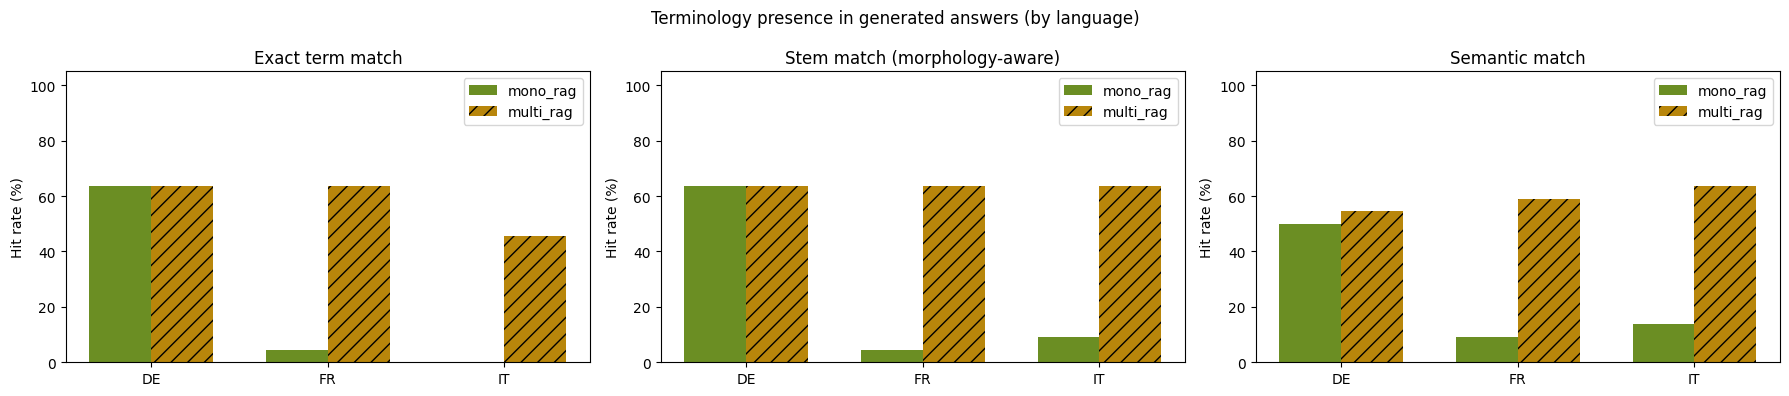

In [11]:
# Chart: terminology match rates by language
if not RUN_TERMINOLOGY or "lang_t" not in dir():
    print("Run the terminology cell first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    langs = lang_t.index.tolist(); x = np.arange(len(langs)); w = 0.35
    for ax, mc, mlc, title in [
        (axes[0], "exact_mono(%)", "exact_multi(%)", "Exact term match"),
        (axes[1], "stem_mono(%)",  "stem_multi(%)",  "Stem match (morphology-aware)"),
        (axes[2], "sem_mono(%)",   "sem_multi(%)",   "Semantic match"),
    ]:
        ax.bar(x - w/2, lang_t[mc],  w, label="mono_rag",  color="olivedrab")
        ax.bar(x + w/2, lang_t[mlc], w, label="multi_rag", color="darkgoldenrod", hatch="//")
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
        ax.set_ylabel("Hit rate (%)"); ax.set_ylim(0, 105)
        ax.set_title(title); ax.legend()
    plt.suptitle("Terminology presence in generated answers (by language)")
    plt.tight_layout(); plt.show()

Loaded terminology results from results\evaluation_results.csv


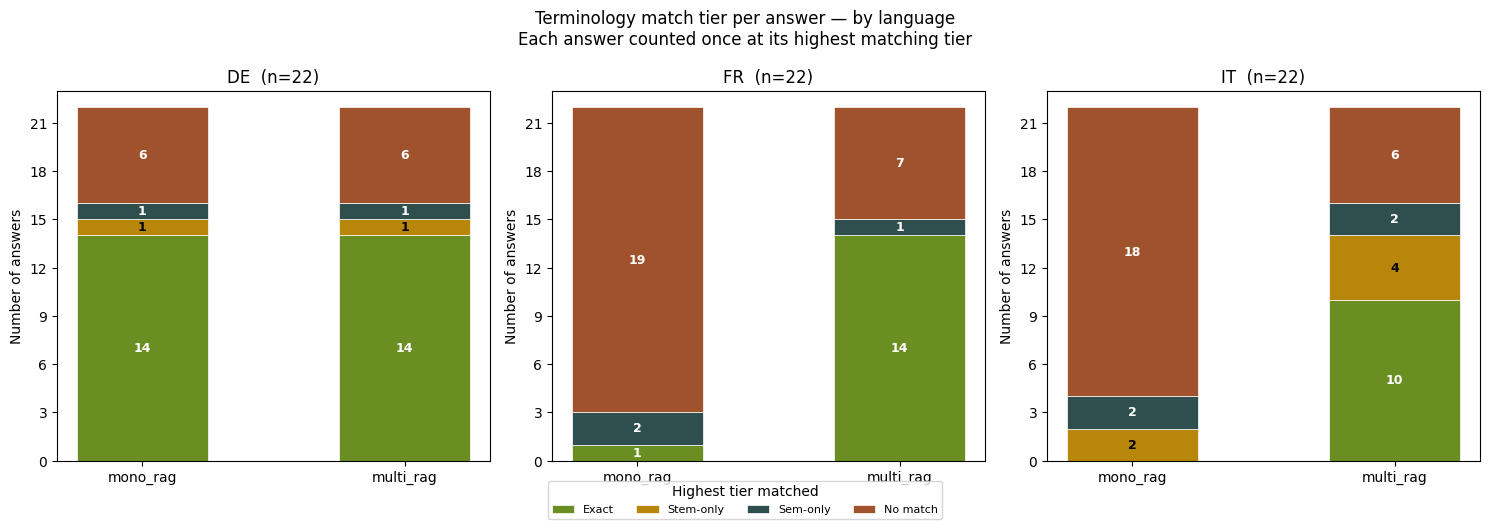

In [3]:
# Chart: match-tier breakdown per answer, split by language
#
# Each answer is assigned to its highest matching tier (mutually exclusive):
#   Exact     — case-insensitive substring hit
#   Stem-only — morphological match but not exact
#   Sem-only  — LLM semantic match but not stem/exact
#   No match  — none of the above
if not RUN_TERMINOLOGY:
    print("RUN_TERMINOLOGY is False — skipping.")
else:
    if "df_t" not in dir():
        if RESULTS_EXPORT.exists():
            df_t = pd.read_csv(RESULTS_EXPORT)
            print(f"Loaded terminology results from {RESULTS_EXPORT}")
        else:
            raise FileNotFoundError(
                f"{RESULTS_EXPORT} not found. Run the terminology cell with RUN_TERMINOLOGY=True first."
            )

    TIERS      = ["Exact", "Stem-only", "Sem-only", "No match"]
    COLORS     = ["olivedrab", "darkgoldenrod", "darkslategray", "sienna"]
    TXT_COLORS = ["white", "black", "white", "white"]

    def _tier_counts(df_sub, suffix):
        exact = df_sub[f"exact_{suffix}"].astype(bool)
        stem  = df_sub[f"stem_{suffix}"].astype(bool)
        sem   = pd.to_numeric(df_sub[f"sem_{suffix}"], errors="coerce").fillna(0).astype(bool)
        counts = {
            "Exact":     int(exact.sum()),
            "Stem-only": int((stem & ~exact).sum()),
            "Sem-only":  int((sem & ~stem & ~exact).sum()),
            "No match":  int((~exact & ~stem & ~sem).sum()),
        }
        assert sum(counts.values()) == len(df_sub), \
            f"Tier counts sum to {sum(counts.values())}, expected {len(df_sub)}"
        return counts

    langs = sorted(df_t["Language"].unique())
    fig, axes = plt.subplots(1, len(langs), figsize=(5 * len(langs), 5))
    if len(langs) == 1:
        axes = [axes]

    bar_x = np.array([0, 1])
    bar_w = 0.5
    legend_handles = []

    for ax, lang in zip(axes, langs):
        df_lang = df_t[df_t["Language"] == lang]
        n = len(df_lang)
        mono_c  = _tier_counts(df_lang, "mono")
        multi_c = _tier_counts(df_lang, "multi")

        bottoms = np.zeros(2)
        for tier, color, tc in zip(TIERS, COLORS, TXT_COLORS):
            vals = np.array([mono_c[tier], multi_c[tier]])
            bars = ax.bar(bar_x, vals, bottom=bottoms, color=color,
                          label=tier, width=bar_w, edgecolor="white", linewidth=0.5)
            if ax is axes[0]:
                legend_handles.append(bars[0])
            for bar, v in zip(bars, vals):
                if v >= 1:
                    yc = bar.get_y() + bar.get_height() / 2
                    ax.text(bar.get_x() + bar.get_width() / 2, yc,
                            str(v), ha="center", va="center",
                            fontsize=9, color=tc, fontweight="bold")
            bottoms += vals

        ax.set_xticks(bar_x)
        ax.set_xticklabels(["mono_rag", "multi_rag"])
        ax.set_title(f"{lang.upper()}  (n={n})")
        ax.set_ylabel("Number of answers")
        ax.set_ylim(0, n + 1)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    fig.legend(legend_handles, TIERS, loc="lower center", ncol=4,
               fontsize=8, title="Highest tier matched",
               bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(
        "Terminology match tier per answer — by language\n"
        "Each answer counted once at its highest matching tier"
    )
    plt.tight_layout()
    plt.show()

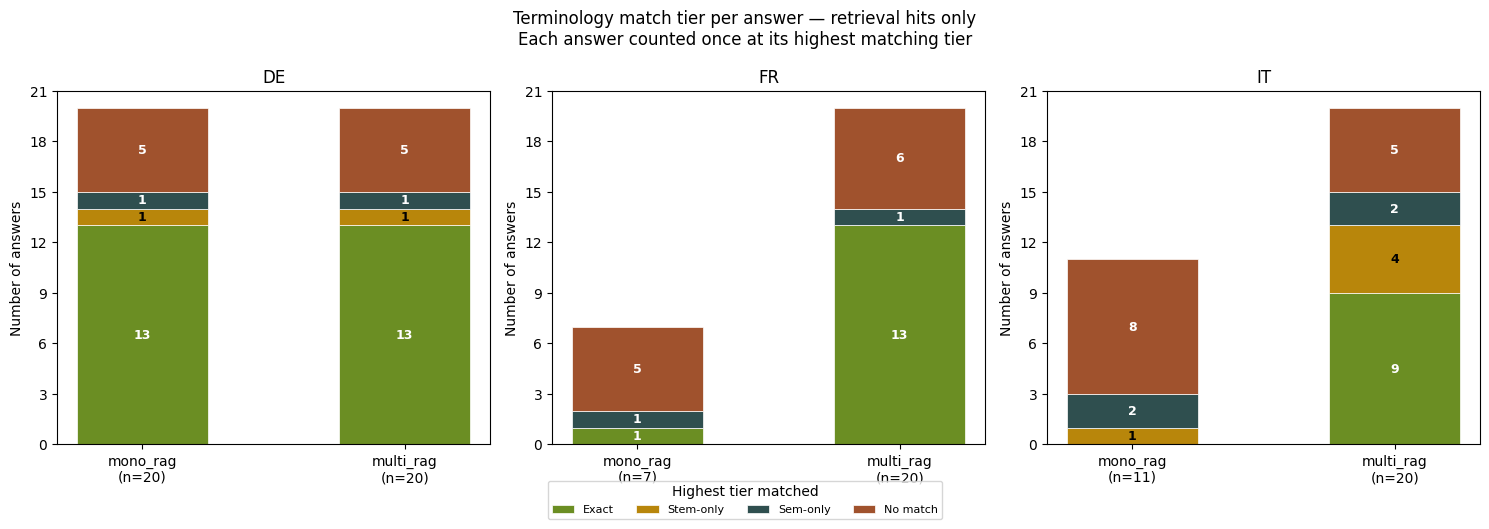

In [ ]:
# Chart: match-tier breakdown — retrieval hits only

if not RUN_TERMINOLOGY:
    print("RUN_TERMINOLOGY is False — skipping.")
else:
    # Load data: prefer in-memory df_t, fall back to saved results CSV
    try:
        _df_th = df_t.copy()
    except NameError:
        if not RESULTS_EXPORT.exists():
            raise FileNotFoundError(
                f"{RESULTS_EXPORT} not found — run the terminology cell or Section 5 export first."
            )
        _df_th = pd.read_csv(RESULTS_EXPORT)
        print(f"Loaded terminology results from {RESULTS_EXPORT}")

    for col in ["exact_mono", "exact_multi", "stem_mono", "stem_multi"]:
        _df_th[col] = _df_th[col].astype(bool)
    for col in ["sem_mono", "sem_multi"]:
        _df_th[col] = pd.to_numeric(_df_th[col], errors="coerce").fillna(0).astype(bool)

    def _tier_counts_hits(df_sub, suffix):
        exact = df_sub[f"exact_{suffix}"].astype(bool)
        stem  = df_sub[f"stem_{suffix}"].astype(bool)
        sem   = pd.to_numeric(df_sub[f"sem_{suffix}"], errors="coerce").fillna(0).astype(bool)
        counts = {
            "Exact":     int(exact.sum()),
            "Stem-only": int((stem & ~exact).sum()),
            "Sem-only":  int((sem & ~stem & ~exact).sum()),
            "No match":  int((~exact & ~stem & ~sem).sum()),
        }
        assert sum(counts.values()) == len(df_sub), \
            f"Tier counts sum to {sum(counts.values())}, expected {len(df_sub)}"
        return counts

    TIERS      = ["Exact", "Stem-only", "Sem-only", "No match"]
    COLORS     = ["olivedrab", "darkgoldenrod", "darkslategray", "sienna"]
    TXT_COLORS = ["white", "black", "white", "white"]

    langs = sorted(_df_th["Language"].unique())
    fig, axes = plt.subplots(1, len(langs), figsize=(5 * len(langs), 5))
    if len(langs) == 1:
        axes = [axes]

    bar_x = np.array([0, 1])
    bar_w = 0.5
    legend_handles = []

    for ax, lang in zip(axes, langs):
        mono_lang  = _df_th[(_df_th["Language"] == lang) & (_df_th["hit_mono"]  == True)]
        multi_lang = _df_th[(_df_th["Language"] == lang) & (_df_th["hit_multi"] == True)]
        n_mono  = len(mono_lang)
        n_multi = len(multi_lang)
        mono_c  = _tier_counts_hits(mono_lang,  "mono")
        multi_c = _tier_counts_hits(multi_lang, "multi")
        n_max   = max(n_mono, n_multi)

        bottoms = np.zeros(2)
        for tier, color, tc in zip(TIERS, COLORS, TXT_COLORS):
            vals = np.array([mono_c[tier], multi_c[tier]])
            bars = ax.bar(bar_x, vals, bottom=bottoms, color=color,
                          label=tier, width=bar_w, edgecolor="white", linewidth=0.5)
            if ax is axes[0]:
                legend_handles.append(bars[0])
            for bar, v in zip(bars, vals):
                if v >= 1:
                    yc = bar.get_y() + bar.get_height() / 2
                    ax.text(bar.get_x() + bar.get_width() / 2, yc,
                            str(v), ha="center", va="center",
                            fontsize=9, color=tc, fontweight="bold")
            bottoms += vals

        ax.set_xticks(bar_x)
        ax.set_xticklabels([f"mono_rag\n(n={n_mono})", f"multi_rag\n(n={n_multi})"])
        ax.set_title(f"{lang.upper()}")
        ax.set_ylabel("Number of answers")
        ax.set_ylim(0, n_max + 1)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    fig.legend(legend_handles, TIERS, loc="lower center", ncol=4,
               fontsize=8, title="Highest tier matched",
               bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(
        "Terminology match tier per answer — retrieval hits only\n"
        "Each answer counted once at its highest matching tier"
    )
    plt.tight_layout()
    plt.show()

In [12]:
# Gap analysis using stem match as the linguistically appropriate baseline.
#
# Two distinct gaps:
#   morph gap  = stem=yes AND exact=no  → correct term used but inflected differently (acceptable)
#   paraph gap = sem=yes  AND stem=no   → concept understood but term genuinely paraphrased (problematic)
if not RUN_TERMINOLOGY or "df_t" not in dir():
    print("RUN_TERMINOLOGY is False or terminology not run yet — skipping gap analysis.")
else:
    morph_gap_mono  = df_t["stem_mono"].astype(bool)  & ~df_t["exact_mono"].astype(bool)
    morph_gap_multi = df_t["stem_multi"].astype(bool) & ~df_t["exact_multi"].astype(bool)
    par_gap_mono    = df_t["sem_mono"].astype(bool)   & ~df_t["stem_mono"].astype(bool)
    par_gap_multi   = df_t["sem_multi"].astype(bool)  & ~df_t["stem_multi"].astype(bool)

    lang_morph = (
        df_t.assign(mono=morph_gap_mono, multi=morph_gap_multi)
            .groupby("Language")[["mono", "multi"]].sum()
            .rename(columns={"mono": "mono_rag", "multi": "multi_rag"})
    )
    lang_par = (
        df_t.assign(mono=par_gap_mono, multi=par_gap_multi)
            .groupby("Language")[["mono", "multi"]].sum()
            .rename(columns={"mono": "mono_rag", "multi": "multi_rag"})
    )

    print("Morphological variation counts (stem=yes, exact=no):")
    display(lang_morph)
    print(f"  Total — mono_rag: {int(morph_gap_mono.sum())}  multi_rag: {int(morph_gap_multi.sum())}")
    print("\nTrue paraphrase gap counts (sem=yes, stem=no):")
    display(lang_par)
    print(f"  Total — mono_rag: {int(par_gap_mono.sum())}  multi_rag: {int(par_gap_multi.sum())}")

Morphological variation counts (stem=yes, exact=no):


,mono_rag,multi_rag
Language,,
de,1,1
fr,0,0
it,2,4


  Total — mono_rag: 3  multi_rag: 5

True paraphrase gap counts (sem=yes, stem=no):


,mono_rag,multi_rag
Language,,
de,1,1
fr,2,1
it,2,2


  Total — mono_rag: 5  multi_rag: 4


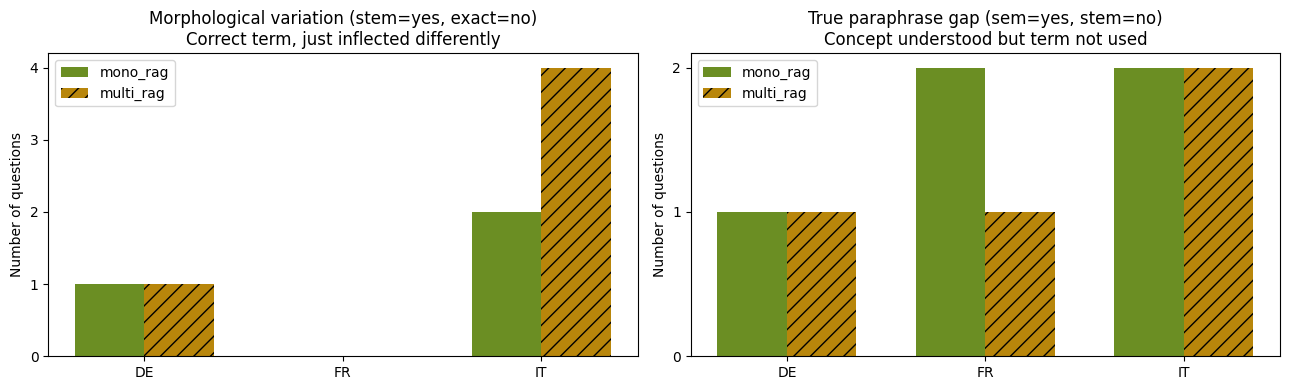

In [13]:
# Chart: morphological variation and paraphrase gap
if not RUN_TERMINOLOGY or "lang_morph" not in dir() or "lang_par" not in dir():
    print("Run the gap analysis cell first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    langs = lang_morph.index.tolist(); x = np.arange(len(langs)); w = 0.35

    for ax, df_gap, title in [
        (axes[0], lang_morph,
         "Morphological variation (stem=yes, exact=no)\nCorrect term, just inflected differently"),
        (axes[1], lang_par,
         "True paraphrase gap (sem=yes, stem=no)\nConcept understood but term not used"),
    ]:
        ax.bar(x - w/2, df_gap["mono_rag"],  w, label="mono_rag",  color="olivedrab")
        ax.bar(x + w/2, df_gap["multi_rag"], w, label="multi_rag", color="darkgoldenrod", hatch="//")
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_ylabel("Number of questions")
        ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

## Section 5 — Summary & Export

Merges all results of this evaluation notebook and exports them to the file `evaluation_results.csv`.

In [14]:
# Merge all results computed in this session
try:
    base = df_answers.copy()
except NameError:
    base = df_q[["ID", "Source Term", "Query", "Language",
                 "Relevant section", "Target Term"]].copy()

if RUN_JUDGE and "df_j" in dir():
    base = base.merge(
        df_j[["ID", "judge_score_mono", "judge_reason_mono",
              "judge_score_multi", "judge_reason_multi", "judge_delta"]],
        on="ID", how="left"
    )

if RUN_TERMINOLOGY and "df_t" in dir():
    base = base.merge(
        df_t[["ID", "exact_mono", "exact_multi",
              "stem_mono", "stem_multi", "sem_mono", "sem_multi"]],
        on="ID", how="left"
    )

base.to_csv(RESULTS_EXPORT, index=False, encoding="utf-8-sig")
print(f"Full results saved to {RESULTS_EXPORT}")
display(base.head(3))

# Summary table
rows = []
if RUN_EVALUATION and "df_answers" in dir():
    rows.append({"Metric": "Retrieval hit rate (%)",
                 "mono_rag": f"{100*df_answers['hit_mono'].mean():.1f}",
                 "multi_rag": f"{100*df_answers['hit_multi'].mean():.1f}"})

if RUN_JUDGE and "df_j" in dir():
    rows.append({"Metric": "Mean judge score (1–5)",
                 "mono_rag": f"{df_j['judge_score_mono'].mean():.2f}",
                 "multi_rag": f"{df_j['judge_score_multi'].mean():.2f}"})

if RUN_TERMINOLOGY and "df_t" in dir():
    rows.append({"Metric": "Exact term match (%)",
                 "mono_rag": f"{100*df_t['exact_mono'].mean():.1f}",
                 "multi_rag": f"{100*df_t['exact_multi'].mean():.1f}"})
    rows.append({"Metric": "Stem match (%)",
                 "mono_rag": f"{100*pd.to_numeric(df_t['stem_mono'],  errors='coerce').mean():.1f}",
                 "multi_rag": f"{100*pd.to_numeric(df_t['stem_multi'], errors='coerce').mean():.1f}"})
    rows.append({"Metric": "Semantic term match (%)",
                 "mono_rag": f"{100*pd.to_numeric(df_t['sem_mono'],  errors='coerce').mean():.1f}",
                 "multi_rag": f"{100*pd.to_numeric(df_t['sem_multi'], errors='coerce').mean():.1f}"})

print("\nSummary:")
display(pd.DataFrame(rows).set_index("Metric"))

Full results saved to results\evaluation_results.csv


,ID,Source Term,Query,Language,Relevant section,Target Term,hit_mono,hit_multi,rerank_mono,rerank_multi,...,judge_reason_mono,judge_score_multi,judge_reason_multi,judge_delta,exact_mono,exact_multi,stem_mono,stem_multi,sem_mono,sem_multi
0,1,Heizer,Was macht ein Heizer?,de,"R 300.13, section 1.1",Feuerung,True,True,1.760924,1.760924,...,The RAG answer accurately and completely addre...,5,The RAG answer accurately and completely addre...,0,True,True,True,True,True,True
1,2,Heizer,Quelles sont les fonctions du chauffeur?,fr,"R 300.13, section 1.1",foyer,False,True,-0.784107,1.611021,...,The reference passage does not contain informa...,4,The answer correctly identifies the functions ...,3,False,True,False,True,False,True
2,3,Heizer,Cosa fa un fuochista?,it,"R 300.13, section 1.1",regolazione del fuoco,True,True,-0.556804,2.042379,...,The RAG answer accurately and completely addre...,5,The RAG answer accurately and completely expla...,0,False,False,False,False,False,True



Summary:


,mono_rag,multi_rag
Metric,,
Retrieval hit rate (%),57.6,90.9
Mean judge score (1–5),3.77,4.14
Exact term match (%),22.7,57.6
Stem match (%),25.8,63.6
Semantic term match (%),24.2,59.1
